In [14]:
#Imports numpy for math, matplotlib for visualizations, noiseProjectBase for base numerical methods and sampling.
import numpy as np
import matplotlib.pyplot as plt
import noiseProjectBase as npb

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [15]:
#Evolves one spin trajectory while applying a 180-degree y-axis Hahn echo pulse at the midpoint.
#Inputs: Alpha and beta are the initial spin amplitudes, Bx and By are magnetic-field components, BzList is the time-dependent Bz field, deltat is the timestep, tmax is the total evolution time, and method selects the numerical evolution method.
#Outputs: Time values, spin amplitudes, X expectation values, and normalization error throughout the evolution.
def solutionHahnEcho(alpha, beta, Bx, By, BzList, deltat, tmax, method):
    timeList = []
    alphaList = []
    betaList = []
    xList = []
    normList = []

    for i in range(int(tmax/deltat)+1):
        timeList.append(deltat*i)
        alphaList.append(alpha)
        betaList.append(beta)
        xList.append(2*(alpha.conjugate()*beta).real)
        normList.append(abs(alpha)*abs(alpha)+abs(beta)*abs(beta)-1)

        if i<int(tmax/deltat):

            #Applies the 180-degree y-axis pulse halfway through the evolution.
            if i==int(tmax/deltat)//2:
                oldAlpha = alpha
                alpha = -beta
                beta = oldAlpha

            #Evolves the spin to the next timestep using RK4 or the exact constant-field solution.
            if method==3:
                alpha, beta = npb.rk4(alpha, beta, Bx, By, BzList, deltat, i)
            if method==4:
                alpha, beta = npb.constantBSolution(alpha, beta, Bx, By, BzList[i], deltat)

    return timeList, alphaList, betaList, xList, normList

In [16]:
#Generates independent time-dependent Bz noise values from a normal distribution.
#Inputs: B0 is the mean magnetic field, sigma is the noise standard deviation, numTrials is the number of trajectories, deltat is the timestep, and tmax is the total evolution time.
#Output: BzData containing all noisy magnetic-field trajectories.
def generateBzData(B0, sigma, numTrials, deltat, tmax):
    return np.random.normal(B0, sigma, (numTrials, int(tmax/deltat)+1))

In [17]:
#Calculates the expected average X signal for time-dependent Gaussian noise with a Hahn echo pulse at the midpoint.
#Inputs: Alpha and beta are the initial amplitudes, B0 is the constant field, sigma is the noise standard deviation, and timeList contains the evolution times.
#Output: Expected average X expectation value throughout the Hahn echo evolution.
def expectedAverageXHahnEcho(alpha, beta, B0, sigma, timeList):
    XList = []

    for i in range(len(timeList)):
        time = timeList[i]

        #Calculates the expected signal before the midpoint pulse.
        if i<=(len(timeList)-1)//2:
            x = 2*np.real(np.conjugate(alpha)*beta*np.exp(B0*time*1.0j*2))*np.exp(-2*sigma*sigma*time*(timeList[1]-timeList[0]))

        #Calculates the expected signal after the midpoint pulse.
        else:
            x = 2*np.real(-np.conjugate(beta)*alpha*np.exp(B0*time*1.0j*2-4*1.0j*B0*timeList[(len(timeList)-1)//2]))*np.exp(-2*sigma*sigma*time*(timeList[1]-timeList[0]))

        XList.append(x)

    return np.array(XList)

In [18]:
#Simulates many noisy Bz trajectories with a Hahn echo and averages their spin evolution.
#Inputs: Alpha and beta are the initial amplitudes, Bx and By are magnetic-field components, BzData contains the noisy trajectories, deltat is the timestep, tmax is the total evolution time, and method selects the numerical method.
#Outputs: Bz trajectories, time values, and ensemble-averaged alpha, beta, X expectation values, and normalization error.
def BzaveragesHahnEcho(alpha, beta, Bx, By, BzData, deltat, tmax, method):
    BzList = []
    alphaList = []
    betaList = []
    XList = []
    normList = []

    #Evolves every noisy trajectory using the Hahn echo sequence.
    for Bz in BzData:
        newTimeList, newAlphaList, newBetaList, newXList, newNormList = solutionHahnEcho(alpha, beta, Bx, By, Bz, deltat, tmax, method)
        BzList.append(Bz)
        alphaList.append(newAlphaList)
        betaList.append(newBetaList)
        XList.append(newXList)
        normList.append(newNormList)

    #Averages the results across all noise trials.
    newAlphaList = np.mean(np.array(alphaList), axis=0)
    newBetaList = np.mean(np.array(betaList), axis=0)
    newXList = np.mean(np.array(XList), axis=0)
    newNormList = np.mean(np.array(normList), axis=0)

    return BzList, newTimeList, newAlphaList, newBetaList, newXList, newNormList

In [19]:
#Analyzes how noise phase accumulated during the first and second halves affects Hahn echo recovery.
#Inputs: BzData contains the magnetic-field trajectories, B0 is the constant field, and deltat is the timestep.
#Outputs: First- and second-half phases, echo and no-echo phases, their variances, covariance, and correlation.
def phaseVarianceAnalysis(BzData, B0, deltat):
    firstHalfList = []
    secondHalfList = []
    phiNoEchoList = []
    phiEchoList = []

    #Calculates the accumulated noise phase during each half of every trajectory.
    for BzList in BzData:
        deltaBzList = BzList-B0
        firstHalf = np.sum(deltaBzList[:(len(BzList)-1)//2])*deltat
        secondHalf = np.sum(deltaBzList[(len(BzList)-1)//2:len(BzList)-1])*deltat

        #Without echo the two phases add, while Hahn echo causes the second-half phase to subtract.
        phiNoEcho = firstHalf+secondHalf
        phiEcho = firstHalf-secondHalf

        firstHalfList.append(firstHalf)
        secondHalfList.append(secondHalf)
        phiNoEchoList.append(phiNoEcho)
        phiEchoList.append(phiEcho)

    firstHalfList = np.array(firstHalfList)
    secondHalfList = np.array(secondHalfList)
    phiNoEchoList = np.array(phiNoEchoList)
    phiEchoList = np.array(phiEchoList)

    #Calculates the statistics describing the relationship between the two halves.
    meanFirst = np.mean(firstHalfList)
    meanSecond = np.mean(secondHalfList)
    varFirst = np.var(firstHalfList)
    varSecond = np.var(secondHalfList)
    covFirstSecond = np.mean((firstHalfList-meanFirst)*(secondHalfList-meanSecond))
    corrFirstSecond = np.corrcoef(firstHalfList, secondHalfList)[0,1]
    varNoEcho = np.var(phiNoEchoList)
    varEcho = np.var(phiEchoList)

    return firstHalfList, secondHalfList, phiNoEchoList, phiEchoList, varFirst, varSecond, covFirstSecond, corrFirstSecond, varNoEcho, varEcho

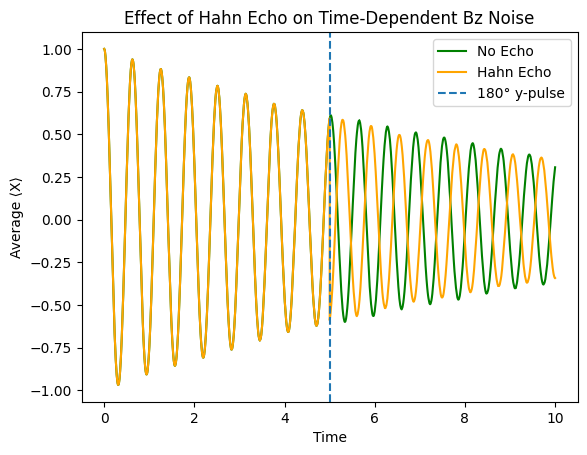

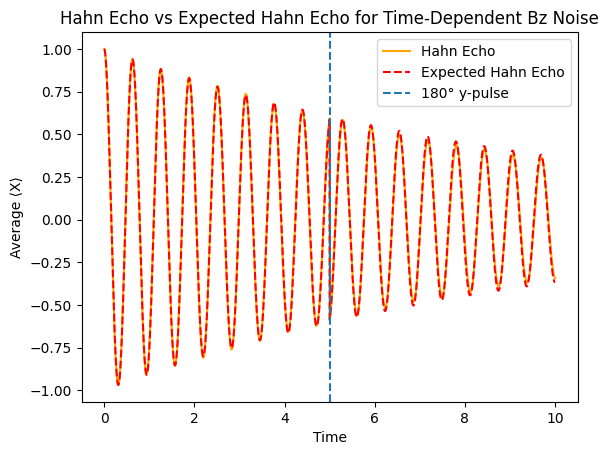

In [20]:
#Defines the initial equal-superposition spin state and parameters for time-dependent Gaussian Bz noise.
alpha0 = 1/np.sqrt(2)
beta0 = 1/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
tmax = 10.0
deltat = 0.001
sigmaSquaredDeltat = 0.05
sigma = np.sqrt(sigmaSquaredDeltat/deltat)
numTrials = 1000

#Generates the same random Bz trajectories for both the no-echo and Hahn echo simulations.
np.random.seed(1)
BzData = generateBzData(B0, sigma, numTrials, deltat, tmax)

#Calculates the ensemble-average evolution without Hahn echo using the base spin-evolution code.
BzList4, newTimeList4, newAlphaList4, newBetaList4, newXList4, newNormList4 = npb.Bzaverages(alpha0, beta0, Bx, By, BzData, deltat, tmax, 4)

#Calculates the ensemble-average evolution with a Hahn echo pulse.
BzListEcho, newTimeListEcho, newAlphaListEcho, newBetaListEcho, newXListEcho, newNormListEcho = BzaveragesHahnEcho(alpha0, beta0, Bx, By, BzData, deltat, tmax, 4)

#Calculates the expected analytical Hahn echo signal for comparison.
expectedXList = expectedAverageXHahnEcho(alpha0, beta0, B0, sigma, newTimeListEcho)

#Compares the spin evolution with and without Hahn echo.
plt.figure(1)
plt.plot(newTimeList4, newXList4, label="No Echo", color="green")
plt.plot(newTimeListEcho, newXListEcho, label="Hahn Echo", color="orange")
plt.axvline(tmax/2, linestyle="--", label="180° y-pulse")
plt.title("Effect of Hahn Echo on Time-Dependent Bz Noise")
plt.xlabel("Time")
plt.ylabel("Average ⟨X⟩")
plt.legend()
plt.show()

#Compares the numerical Hahn echo result with the expected analytical signal.
plt.figure(2)
plt.plot(newTimeListEcho, newXListEcho, label="Hahn Echo", color="orange")
plt.plot(newTimeListEcho, expectedXList, label="Expected Hahn Echo", color="red", linestyle="--")
plt.axvline(tmax/2, linestyle="--", label="180° y-pulse")
plt.title("Hahn Echo vs Expected Hahn Echo for Time-Dependent Bz Noise")
plt.xlabel("Time")
plt.ylabel("Average ⟨X⟩")
plt.legend()
plt.show()

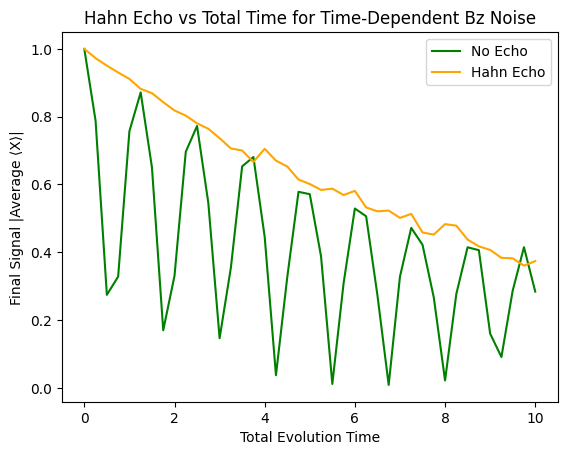

In [21]:
#Defines the initial spin state and parameters used to measure the final signal over different total evolution times.
alpha0 = 1/np.sqrt(2)
beta0 = 1/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
deltat = 0.001
tmax = 10.0
sigmaSquaredDeltat = 0.05
sigma = np.sqrt(sigmaSquaredDeltat/deltat)
numTrials = 1000

np.random.seed(1)

#Creates the total evolution times that will be tested.
totalTimeList = np.arange(0.0, tmax+0.25, 0.25)
finalNoEchoTD = []
finalEchoTD = []

#Runs a separate no-echo and Hahn echo simulation for each total evolution time.
for time in totalTimeList:
    count = int(time/deltat)

    #Ensures there is an even number of timesteps so the Hahn pulse has an exact midpoint.
    if count%2==1:
        count = count+1

    if count==0:
        finalNoEchoTD.append(1.0)
        finalEchoTD.append(1.0)
    else:
        BzDataRun = generateBzData(B0, sigma, numTrials, deltat, count*deltat)

        #Calculates the final signal without Hahn echo.
        BzListNoEcho, timeNoEcho, alphaNoEcho, betaNoEcho, xNoEcho, normNoEcho = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataRun, deltat, count*deltat, 4)

        #Calculates the final signal with Hahn echo.
        BzListEchoRun, timeEchoRun, alphaEchoRun, betaEchoRun, xEchoRun, normEchoRun = BzaveragesHahnEcho(alpha0, beta0, Bx, By, BzDataRun, deltat, count*deltat, 4)

        finalNoEchoTD.append(abs(xNoEcho[-1]))
        finalEchoTD.append(abs(xEchoRun[-1]))

#Plots the final signal as a function of total evolution time.
plt.plot(totalTimeList, finalNoEchoTD, label="No Echo", color="green")
plt.plot(totalTimeList, finalEchoTD, label="Hahn Echo", color="orange")
plt.title("Hahn Echo vs Total Time for Time-Dependent Bz Noise")
plt.xlabel("Total Evolution Time")
plt.ylabel("Final Signal |Average ⟨X⟩|")
plt.legend()
plt.show()

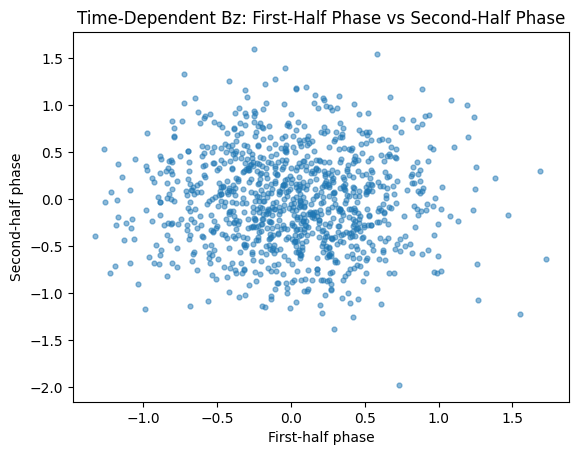

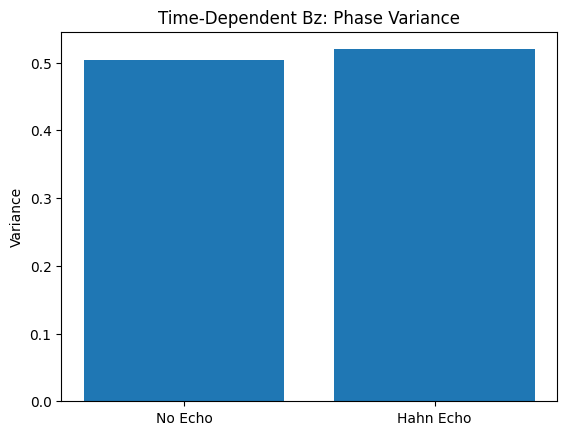

In [22]:
#Calculates the phase accumulated during the first and second halves of each time-dependent noise trajectory.
firstTD, secondTD, phiNoEchoTD, phiEchoTD, varFirstTD, varSecondTD, covTD, corrTD, varNoEchoTD, varEchoTD = phaseVarianceAnalysis(BzData, B0, deltat)

#Shows how strongly the first-half and second-half accumulated phases are related.
plt.scatter(firstTD, secondTD, s=12, alpha=0.5)
plt.title("Time-Dependent Bz: First-Half Phase vs Second-Half Phase")
plt.xlabel("First-half phase")
plt.ylabel("Second-half phase")
plt.show()

#Compares phase variance without Hahn echo to phase variance after Hahn echo.
plt.bar(["No Echo", "Hahn Echo"], [varNoEchoTD, varEchoTD])
plt.title("Time-Dependent Bz: Phase Variance")
plt.ylabel("Variance")
plt.show()